In [15]:
"""
    given fp16 model, sample image, and bboxes
    confirm token strings look okay 
    min depth values are populated for the ewtracted tokens and strings

    plan
    - load sample images
    - load model
    - load banks
    - draw bboxes on image
        - on relevant patches
    - run the images through the model and collect embeddings
    - get nearest token strings
    - get depth values
    - sanity check both the results


"""
# Autoreload
%load_ext autoreload
%autoreload 2

import csv
import json
import random
import subprocess
import sys
from pathlib import Path

import requests
from PIL import Image
import datasets
import numpy as np
import torch
from io import BytesIO
from matplotlib import pyplot as plt
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration


# load images
num_images = 5
FIXED_RESOLUTION = 448  # → 16×16 merged token grid (256 visual tokens)
seed = 42
_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed = 42
seed_all(seed)

def _ensure_nlp_resources():
    print("\nChecking NLP resources...")
    import nltk
    try:
        wn = __import__("nltk.corpus", fromlist=["wordnet"]).wordnet
        wn.synsets("dog")
    except Exception:
        print("  Downloading NLTK wordnet + omw-1.4...")
        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)

    try:
        import spacy
        spacy.load("en_core_web_sm")
    except OSError:
        print("  Downloading spaCy en_core_web_sm...")
        subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)

    print("  NLP resources OK")

_ensure_nlp_resources()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Checking NLP resources...


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
/root/miniconda3/envs/latentlens-exp-env/lib/python3.11/site-packages/debugpy/_vendored/force_pydevd.py:18: UserWarning: incompatible copy of pydevd already imported:
 /root/miniconda3/envs/latentlens-exp-env/lib/python3.11/site-packages/pydevd_plugins/extensions/pydevd_plugin_omegaconf.py
  warnings.warn(msg + ':\n {}'.format('\n  '.join(_unvendored)))
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
/root/miniconda3/envs/latentlens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.9 MB/s  0:00:00m0:00:010:01


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
  NLP resources OK


In [3]:
model_dir = Path("/workspace/latentlens/experiment/data/Qwen2-VL-7B-Instruct")
index_dir = Path("/workspace/latentlens/experiment/data/latentlens-qwen2vl-embeddings")
data_dir = Path("/workspace/latentlens/experiment/data/pixmo_cap")



def load_images(data_dir: Path, num_images = 5):

    def _fetch_image(url: str) -> Image.Image:
        r = requests.get(url, stream=True, timeout=10, headers=_HEADERS)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")

    ds = datasets.load_from_disk(data_dir)['validation']
    results = []
    idx = 0
    while len(results) < num_images and idx < len(ds):
        row = ds[idx]
        try:
            image = _fetch_image(row["image_url"])
            results.append({
                "idx": idx,
                "image_url": row["image_url"],
                "image": image,
                "caption": row["caption"],
            })
            print(f"  [{len(results)}/{num_images}] val_idx={idx} — {row['image_url'][:70]}")
        except Exception as e:
            print(f"  Skipped val_idx={idx}: {e}")
        idx += 1
    return results

def show_image(image: Image.Image):
    plt.imshow(image)
    plt.axis("off")
    plt.show()


images = load_images(data_dir)

  [1/5] val_idx=0 — https://img.freepik.com/premium-photo/red-kidney-bean-is-variety-commo
  [2/5] val_idx=1 — https://i.redd.it/hvxnfy7wuwxc1.png
  [3/5] val_idx=2 — http://i.imgur.com/doSWm.png
  [4/5] val_idx=3 — https://1.bp.blogspot.com/-qy9fh1m70Fk/WhH5wf-AgnI/AAAAAAAAlrY/fxf3N2F
  [5/5] val_idx=4 — https://techcult.com/wp-content/uploads/2021/07/Tap-on-the-three-dots-


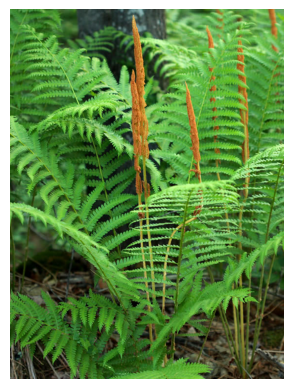

In [8]:
show_image(images[3]["image"])

In [5]:
# load model
def load_model(model_dir: Path):
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        str(model_dir), torch_dtype=torch.float16, device_map="auto"
    )

    model.eval()

    processor = AutoProcessor.from_pretrained(str(model_dir))
    px = FIXED_RESOLUTION * FIXED_RESOLUTION
    processor.image_processor.min_pixels = px
    processor.image_processor.max_pixels = px
    processor.image_processor.do_resize = False

    print(f"  Loaded model on {model.device}, resolution locked to {FIXED_RESOLUTION}×{FIXED_RESOLUTION}")
    return model, processor


model, processor= load_model(model_dir)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


  Loaded model on cuda:0, resolution locked to 448×448


In [12]:
from dataclasses import dataclass

@dataclass
class Bank:
    embeddings: torch.Tensor   # [N, hidden_dim] float16, kept on CPU
    metadata: list             # [{token_str, token_id, caption, position}, ...]


def load_banks(index_dir: Path, layers: list = None) -> dict:
    """Load reference embedding banks. Returns {layer: Bank}.
    If layers is None, loads all available layer_* directories."""
    if layers is None:
        layers = sorted(
            int(p.name.split("_")[1])
            for p in index_dir.iterdir()
            if p.is_dir() and p.name.startswith("layer_")
        )

    banks = {}
    for L in layers:
        path = index_dir / f"layer_{L}" / "embeddings_cache.pt"
        print(f"  Loading layer {L} from {path.name}...", end=" ", flush=True)
        data = torch.load(path, map_location="cpu", weights_only=False)
        banks[L] = Bank(embeddings=data["embeddings"], metadata=data["metadata"])
        e = data["embeddings"]
        print(f"shape={list(e.shape)} dtype={e.dtype}")

    return banks


banks = load_banks(index_dir)

  Loading layer 1 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 2 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 4 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 8 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 16 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 24 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 26 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 27 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16


In [10]:
# draw bboxes on image
from PIL import ImageDraw

IMAGE_PAD_TOKEN_ID = 151655  # <|image_pad|> in Qwen2-VL vocabulary


def get_images_with_bboxes(images, processor, seed=42):

    def _center_crop_square(img: Image.Image) -> Image.Image:
        w, h = img.size
        s = min(w, h)
        return img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))

    def draw_bboxes(record: dict, image_idx: int) -> dict:

        processed = _center_crop_square(record["image"]).resize(
            (FIXED_RESOLUTION, FIXED_RESOLUTION), Image.LANCZOS
        )
        # 448, 448
        # print(f"processed size - {processed.size}")

        # 448, 448 -> with each patch size of 14, 14, you'll have 28x28 = 784 patches
        inputs = processor(
            images=[processed],
            text="<|image_pad|>Describe this image.",
            return_tensors="pt",
        )
        # print(f"image grid thw - {inputs['image_grid_thw']}")
        # print(f"pixel values - {inputs['pixel_values'].shape}")

        # Derive merged token grid from image_grid_thw
        thw = inputs["image_grid_thw"]        # [1, 3]: (temporal, grid_h, grid_w)
        _, gh, gw = thw[0].tolist()
        merge_size = processor.image_processor.merge_size   # = 2
        # 32 // 2 = 16, llm seems 16 x 16 (256) total patches/tokens each of size 14 x 14
        H = int(gh) // merge_size
        W = int(gw) // merge_size
        # 448 // 16 = 28, 16 by 16 is what the llm sees, it corresponds to 28 x 28 patches of the original image
        merged_patch_px = FIXED_RESOLUTION // W             # = 28px per merged patch

        # Locate vision tokens
        input_ids = inputs["input_ids"][0]
        positions = (input_ids == IMAGE_PAD_TOKEN_ID).nonzero(as_tuple=True)[0]
        vision_start = int(positions[0])
        num_vision = len(positions)

        # print(f"num_vision - {num_vision}")

        # Pick selected patch: random choice from top-10 highest-variance patches
        img_arr = np.array(processed)
        variances = [
            float(img_arr[r * merged_patch_px:(r + 1) * merged_patch_px,
                           c * merged_patch_px:(c + 1) * merged_patch_px].var())
            for r in range(H) for c in range(W)
        ]
        top10_indices = sorted(range(H * W), key=lambda i: variances[i], reverse=True)[:10]
        selected_patch = random.Random(seed + image_idx).choice(top10_indices)

        # Draw all top-10 patches (blue), highlight selected patch (red)
        overlay = processed.copy()
        draw = ImageDraw.Draw(overlay)
        for patch_idx in top10_indices:
            row = patch_idx // W
            col = patch_idx % W
            x1, y1 = col * merged_patch_px, row * merged_patch_px
            x2, y2 = x1 + merged_patch_px, y1 + merged_patch_px
            color = "red" if patch_idx == selected_patch else "blue"
            width = 3 if patch_idx == selected_patch else 1
            draw.rectangle([x1, y1, x2, y2], outline=color, width=width)

        sel_row, sel_col = selected_patch // W, selected_patch % W
        bbox = [
            sel_col * merged_patch_px,
            sel_row * merged_patch_px,
            (sel_col + 1) * merged_patch_px,
            (sel_row + 1) * merged_patch_px,
        ]

        return {
            **record,
            "processed": processed,
            "image_with_bboxes": overlay,
            "patch_idx": selected_patch,
            "bbox": bbox,
            "grid": [H, W],
            "vision_start": vision_start,
            "num_vision": num_vision,
        }

    results = []
    for i, record in enumerate(images):
        print(f"  Image {i + 1}/{len(images)} — val_idx={record['idx']}")
        results.append(draw_bboxes(record, i))
    return results


images_with_bboxes = get_images_with_bboxes(images, processor)


  Image 1/5 — val_idx=0
  Image 2/5 — val_idx=1
  Image 3/5 — val_idx=2
  Image 4/5 — val_idx=3
  Image 5/5 — val_idx=4


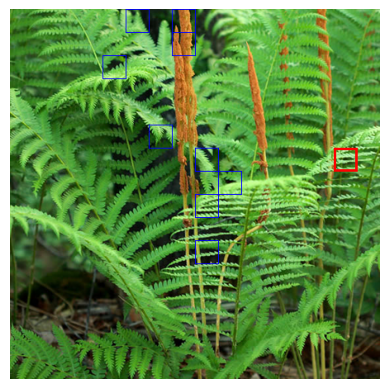

In [11]:
show_image(images_with_bboxes[3]["image_with_bboxes"])

In [16]:
import torch.nn.functional as F

VISUAL_LAYERS = [1, 2, 4, 8, 16, 24, 27]


def get_image_results(
    images_with_bboxes,
    model,
    processor,
    banks,
    visual_layers=None,
    top_k=5,
    search_top_k=10,
):
    """For each image patch, return top_k closest phrases pooled across all visual and reference layers."""
    if visual_layers is None:
        visual_layers = VISUAL_LAYERS

    device = next(model.parameters()).device

    def extract_hidden_states(record: dict) -> dict:
        inputs = processor(
            images=[record["processed"]],
            text="<|image_pad|>Describe this image.",
            return_tensors="pt",
        )
        inputs = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in inputs.items()
        }

        with torch.inference_mode():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states
        vision_start = record["vision_start"]
        patch_idx = record["patch_idx"]

        hs_by_layer = {}
        for layer in visual_layers:
            if layer >= len(hidden_states):
                print(f"  Warning: visual_layer={layer} out of range ({len(hidden_states)} total)")
                continue
            hs_by_layer[layer] = hidden_states[layer][0, vision_start + patch_idx, :].float().cpu()
        return hs_by_layer

    def search_top_phrases(hs_by_layer: dict) -> list:
        candidates = []
        for visual_layer, query in hs_by_layer.items():
            query_norm = F.normalize(query.float(), dim=-1).to(device)

            for bank_layer, bank in banks.items():
                emb = bank.embeddings.to(device).float()
                emb_norm = F.normalize(emb, dim=-1)
                sims = query_norm @ emb_norm.T

                k = min(search_top_k, sims.shape[0])
                vals, idxs = torch.topk(sims, k=k)

                for sim, idx in zip(vals.cpu().tolist(), idxs.cpu().tolist()):
                    meta = bank.metadata[idx]
                    candidates.append({
                        "token_str": meta["token_str"],
                        "similarity": sim,
                        "caption": meta["caption"],
                        "visual_layer": visual_layer,
                        "contextual_layer": bank_layer,
                    })

                del emb, emb_norm, sims
                if device.type == "cuda":
                    torch.cuda.empty_cache()

        candidates.sort(key=lambda c: c["similarity"], reverse=True)

        seen = set()
        top_phrases = []
        for c in candidates:
            key = c["token_str"].strip().lower()
            if not key or key in seen:
                continue
            seen.add(key)
            top_phrases.append({
                "token_str": c["token_str"],
                "similarity": round(c["similarity"], 4),
                "caption": c["caption"],
                "visual_layer": c["visual_layer"],
                "contextual_layer": c["contextual_layer"],
            })
            if len(top_phrases) >= top_k:
                break

        return top_phrases

    results = []
    for i, record in enumerate(images_with_bboxes):
        print(f"  Image {i + 1}/{len(images_with_bboxes)} — val_idx={record['idx']}")
        hs_by_layer = extract_hidden_states(record)
        top5 = search_top_phrases(hs_by_layer)
        results.append({
            "idx": record["idx"],
            "image_url": record["image_url"],
            "caption": record["caption"],
            "patch_idx": record["patch_idx"],
            "bbox": record["bbox"],
            "top5": top5,
        })
        for rank, phrase in enumerate(top5, start=1):
            print(
                f"    {rank}. {phrase['token_str']!r} "
                f"(sim={phrase['similarity']}, vL={phrase['visual_layer']}, cL={phrase['contextual_layer']})"
            )
        break

    return results


image_results = get_image_results(images_with_bboxes, model, processor, banks)

  Image 1/5 — val_idx=0


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.02 GiB. GPU 0 has a total capacity of 22.04 GiB of which 2.09 GiB is free. Including non-PyTorch memory, this process has 19.95 GiB memory in use. Of the allocated memory 19.47 GiB is allocated by PyTorch, and 247.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)